# 📌 Analisis Sentimen Masyarakat terhadap Proyek Transportasi Modern di Indonesia melalui Komentar YouTube


## 1. Business Understanding
### Latar Belakang

Infrastruktur transportasi modern seperti Kereta Cepat Whoosh, MRT Jakarta, dan LRT Jabodebek merupakan bagian dari transformasi sistem transportasi nasional. Kehadiran proyek-proyek tersebut memunculkan berbagai respons dari masyarakat yang dapat diamati melalui media sosial, salah satunya YouTube.

Komentar pengguna YouTube mengandung opini, pengalaman, serta persepsi masyarakat terhadap kualitas layanan, manfaat ekonomi, kenyamanan, hingga efektivitas pembangunan transportasi modern.

Analisis sentimen dapat digunakan untuk mengidentifikasi kecenderungan opini masyarakat secara otomatis menggunakan teknik Natural Language Processing (NLP).

### Tujuan
1. Mengumpulkan komentar publik dari YouTube.
2. Mengklasifikasikan sentimen menjadi positif, netral, dan negatif.
3. Membangun model machine learning dan deep learning.
4. Membandingkan performa beberapa algoritma.

Ipnyb ini akan melanjutkan file ipnyb scraping, beserta dengan penomoran subbab yang akan dimulai dari 12. Pelabelan Sentimen (Lexicode)

In [1]:
!pip install google-api-python-client
!pip install pandas
!pip install numpy
!pip install tqdm
!pip install Sastrawi
!pip install wordcloud
!pip install tensorflow
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib

In [2]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

In [3]:
df = pd.read_csv(
    "dataset_transportasi_raw.csv"
)

##12. Pelabelan Sentimen (Lexicon)

###Tujuan
Memberikan label sentimen pada setiap komentar sehingga dapat digunakan sebagai data pelatihan model klasifikasi sentimen. Pelabelan dilakukan menggunakan pendekatan lexicon-based yang menggabungkan kosakata bahasa Indonesia, bahasa Jawa, dan istilah yang umum digunakan pada sektor properti dan konstruksi.

In [4]:
positif_words = [

    "cepat",
    "modern",
    "maju",
    "nyaman",
    "bagus",
    "mantap",
    "keren",
    "hebat",
    "bersih",
    "rapi",
    "aman",
    "efisien",
    "membantu",
    "bermanfaat",
    "terbaik",
    "top",
    "suka",
    "bangga",
    "luar biasa",
    "mantul",
    "jos",
    "canggih",
    "praktis",
    "mudah",
    "recommended",
    "recommend",
    "good",
    "great",
    "excellent",
    "cepat",
    "modern",
    "maju",
    "nyaman",
    "bersih",
    "aman",
    "praktis",
    "efisien",
    "bagus",
    "keren",
    "mantap",
    "hebat",
    "bangga",
    "terintegrasi",
    "canggih",
    "recommended",
    "top",
    "luar biasa",
    "best",
    "mantul"
]

negatif_words = [

    "mahal",
    "lambat",
    "telat",
    "terlambat",
    "gagal",
    "rugi",
    "utang",
    "sepi",
    "jelek",
    "buruk",
    "parah",
    "korupsi",
    "mangkrak",
    "bohong",
    "kecewa",
    "ribet",
    "susah",
    "macet",
    "overpriced",
    "zonk",
    "amburadul",
    "boros",
    "tidak berguna",
    "percuma",
    "mahal",
    "rugi",
    "utang",
    "gagal",
    "gatot",
    "zonk",
    "jelek",
    "buruk",
    "parah",
    "lambat",
    "telat",
    "terlambat",
    "mangkrak",
    "korupsi",
    "tikus",
    "garong",
    "bohong",
    "kecewa",
    "macet",
    "masalah",
    "kesalahan",
    "ga",
    "ga worth",
    "gk worth it",
    "bobrok",
    "ngelawak",
    "salah",
    "too bad",
    "carut marut",
    "longor",
    "kedzoliman",
    "not found",
    "overpriced"
]

In [5]:
def sentiment_label(text):

    text = str(text).lower()

    pos_score = 0
    neg_score = 0

    for word in positif_words:
        if word in text:
            pos_score += 1

    for word in negatif_words:
        if word in text:
            neg_score += 1

    if pos_score >= neg_score + 1:
        return "positif"

    elif neg_score >= pos_score + 1:
        return "negatif"

    else:
        return "netral"

In [6]:
df["sentiment"] = df["comment"].apply(
    sentiment_label
)

In [7]:
df["sentiment"].value_counts()

,count
sentiment,
netral,15328
negatif,10299
positif,6377


In [8]:
df[df["sentiment"]=="netral"][
    ["comment"]
].sample(50)

,comment
23007,Yg sebelah mau perubahan lagi😂😂😂
1080,Sudah ditentang oleh designernya.
7285,"Uang pajak ku,,buat bayar infrastruktur transp..."
5356,Peradaban???
25162,Maybe that time Indonesian people was holiday
1200,Hm..kekecilan.....mungkin...dikorup dikit tu
13299,Tarif nya ngeri yah😢
21695,Bah murahya daripada naik travel
25451,Udah pernah pas masih gratis 🎉❤❤😂
21677,kaya keretanya Kamen rider anjir


### Insight

Hasil pelabelan menunjukkan bahwa sentimen netral mendominasi dataset dengan 15.328 komentar, diikuti sentimen negatif sebanyak 10.299 komentar dan sentimen positif sebanyak 6.377 komentar.

Distribusi ini menunjukkan bahwa masyarakat tidak hanya memberikan apresiasi terhadap transportasi modern Indonesia, tetapi juga menyampaikan kritik dan komentar informatif sehingga dataset memiliki variasi sentimen yang cukup baik untuk proses pelatihan model.

##13. Simpan Dataset Berlabel
###Tujuan
Menyimpan dataset yang telah memiliki label sentimen sehingga dapat digunakan pada tahap preprocessing dan pelatihan model.

In [9]:
df.to_csv(
    "dataset_transportasi_labeled.csv",
    index=False
)

##14. Evaluasi Labeling - Distribusi Sentimen
###Tujuan
Melihat persebaran sentimen hasil pelabelan.

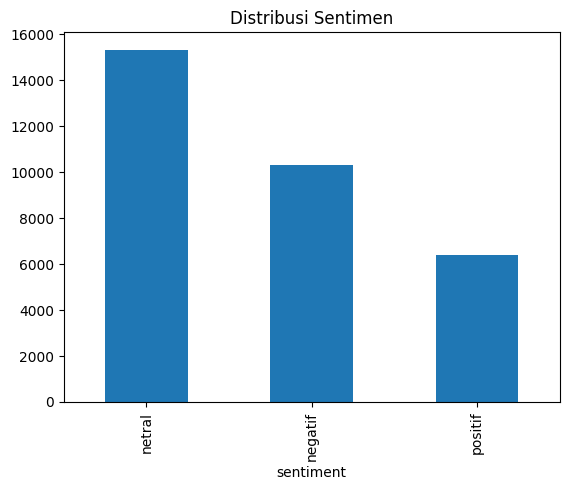

In [10]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribusi Sentimen"
)

plt.show()

In [11]:
  df["sentiment"].value_counts(
    normalize=True
) * 100

,proportion
sentiment,
netral,47.894013
negatif,32.180352
positif,19.925634


### Insight

Distribusi sentimen menunjukkan bahwa kelas netral mendominasi dataset dengan proporsi sebesar 47,89%, diikuti oleh sentimen negatif sebesar 32,18% dan sentimen positif sebesar 19,92%.

Dominasi sentimen netral menunjukkan bahwa sebagian besar komentar YouTube terkait transportasi modern Indonesia bersifat informatif, diskusi umum, pertanyaan, atau tanggapan yang tidak secara eksplisit menunjukkan opini positif maupun negatif.

Di sisi lain, proporsi sentimen negatif yang cukup tinggi menunjukkan bahwa masyarakat juga aktif menyampaikan kritik terhadap berbagai aspek proyek transportasi modern, seperti biaya pembangunan, kebijakan pemerintah, operasional, maupun dampak ekonomi. Sementara itu, sentimen positif mencerminkan apresiasi masyarakat terhadap manfaat transportasi modern seperti peningkatan konektivitas, efisiensi waktu perjalanan, serta kemajuan infrastruktur nasional.

Meskipun distribusi kelas tidak sepenuhnya seimbang, proporsi ketiga kelas masih cukup representatif untuk digunakan dalam proses pelatihan model klasifikasi sentimen multiclass.

##15. Text Preprocessing
###Tujuan
Membersihkan teks komentar agar lebih mudah diproses oleh model machine learning dan deep learning.
Tahapan:
1. Case Folding & Cleaning Text
2. Stopword Removal
3. Stemming
4. Pembuatan Final Processed Text

In [12]:
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

## 15.1 Case Folding & Cleaning Text
###Tujuan
Mengubah teks menjadi huruf kecil dan menghapus:
- URL
- HTML
- angka
- emoji
- tanda baca

In [13]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(
        r"[^\w\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [14]:
df["clean_comment"] = df["comment"].apply(
    clean_text
)

df[
    [
        "comment",
        "clean_comment"
    ]
].head(10)

,comment,clean_comment
0,Dana MBG 235 trilyun setahun. Itu lebih dari c...,dana mbg trilyun setahun itu lebih dari cukup ...
1,Gak jalan 😂 sama kayak hambalang,gak jalan sama kayak hambalang
2,Ahy mendukung wosh sama saja membunuh menguran...,ahy mendukung wosh sama saja membunuh menguran...
3,Kemampuan menteri dan era kepemimpinan sekaran...,kemampuan menteri dan era kepemimpinan sekaran...
4,Ga bakal jadi klo AHY yg urus infrastruktur. D...,ga bakal jadi klo ahy yg urus infrastruktur di...
5,😂😂😂😂😂😂😂 halah bos ojo halu teko surabaya ae ur...,halah bos ojo halu teko surabaya ae urung kok ...
6,Jawa mulu pemerataan ekonomi tahi kuching. Ad...,jawa mulu pemerataan ekonomi tahi kuching ada ...
7,Utang udah numpuk mau ngutang lagi ini anak in...,utang udah numpuk mau ngutang lagi ini anak in...
8,Duit gede lagiiiii,duit gede lagiiiii
9,Boleh itu,boleh itu


##15.2 Stopword Removal
###Tujuan
Menghapus kata yang tidak memiliki makna penting.

In [15]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()

stopwords = set(
    factory.get_stop_words()
)

In [16]:
custom_stopwords = {

    "nya","yg","aja",
    "nih","dong","sih",
    "kak","pak","bu",

    "nih","lah","kok",
    "deh","ya","jadi",

    "bang","mas","mba",
    "mbak","bro","sis",

    "nih","itu","ini",

    "aku","saya","gua",
    "gw","gue",

    "sampe","udah",
    "dah","aja"
}

stopwords.update(
    custom_stopwords
)

In [17]:
def remove_stopwords(text):

    words = text.split()

    words = [

        word

        for word in words

        if word not in stopwords

    ]

    return " ".join(words)

In [18]:
df["no_stopwords"] = df[
    "clean_comment"
].apply(
    remove_stopwords
)

df[
    [
        "clean_comment",
        "no_stopwords"
    ]
].head(10)

,clean_comment,no_stopwords
0,dana mbg trilyun setahun itu lebih dari cukup ...,dana mbg trilyun setahun lebih cukup membangun...
1,gak jalan sama kayak hambalang,gak jalan sama kayak hambalang
2,ahy mendukung wosh sama saja membunuh menguran...,ahy mendukung wosh sama membunuh mengurangi pe...
3,kemampuan menteri dan era kepemimpinan sekaran...,kemampuan menteri era kepemimpinan sekarang ra...
4,ga bakal jadi klo ahy yg urus infrastruktur di...,ga bakal klo ahy urus infrastruktur takut
5,halah bos ojo halu teko surabaya ae urung kok ...,halah bos ojo halu teko surabaya ae urung sak ...
6,jawa mulu pemerataan ekonomi tahi kuching ada ...,jawa mulu pemerataan ekonomi tahi kuching noh ...
7,utang udah numpuk mau ngutang lagi ini anak in...,utang numpuk mau ngutang anak ingusan
8,duit gede lagiiiii,duit gede lagiiiii
9,boleh itu,


In [19]:
import re

def normalize_repeated_chars(text):

    text = re.sub(
        r'(.)\1{2,}',
        r'\1\1',
        text
    )

    return text

In [20]:
df["normalized"] = (
    df["no_stopwords"]
    .apply(normalize_repeated_chars)
)

In [21]:
slang_dict = {

    "gak": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",

    "bgt": "banget",
    "yg": "yang",
    "dr": "dari",
    "udh": "sudah",
    "dgn": "dengan",

    "tp": "tapi",
    "krn": "karena",
    "aja": "saja",

    "klo": "kalau",
    "kalo": "kalau",

    "jgn": "jangan",
    "org": "orang",
    "krn": "karena",

    "dpt": "dapat",
    "utk": "untuk",
    "pd": "pada",

    "aja": "saja",
    "ajaa": "saja",

    "bgt": "banget",
    "bngt": "banget",

    "gw": "saya",
    "gue": "saya",

    "lu": "kamu",
    "loe": "kamu",

    "tdk": "tidak"
}

In [22]:
def normalize_slang(text):

    words = text.split()

    normalized = [
        slang_dict.get(word, word)
        for word in words
    ]

    return " ".join(normalized)

In [23]:
df["normalized"] = (
    df["normalized"]
    .apply(normalize_slang)
)

In [24]:
df[
    [
        "no_stopwords",
        "normalized"
    ]
].sample(20)

,no_stopwords,normalized
19669,wow jet darat,wow jet darat
5516,keren subsidi artinya pendapatan menutupi,keren subsidi artinya pendapatan menutupi
25884,i would spend the k on solaria and llao llao g...,i would spend the k on solaria and llao llao g...
12978,lepas jatuh cinta confirm jatuh tangga,lepas jatuh cinta confirm jatuh tangga
2023,jelas kelihatan kesalahan design krn design td...,jelas kelihatan kesalahan design karena design...
18340,ᴍᴏᴠᴇ ᴏɴ ᴅᴏɴᴋ,ᴍᴏᴠᴇ ᴏɴ ᴅᴏɴᴋ
1314,untung nga d bongkar kaya tiang kereta cepat,untung nga d bongkar kaya tiang kereta cepat
8307,jalan tempat wisata dijkt sekitarnya misal keb...,jalan tempat wisata dijkt sekitarnya misal keb...
13694,i don t know president,i don t know president
15833,can t wait for tj to ruin their corridor once ...,can t wait for tj to ruin their corridor once ...


## 15.3 Stemming
###Tujuan
Stemming merupakan proses mengubah kata berimbuhan menjadi bentuk dasarnya. Contohnya pembangunan menjadi bangun, pengelolaan menjadi kelola, dsb.

Pada penelitian ini dilakukan percobaan stemming menggunakan algoritma Sastrawi. Namun, proses stemming membutuhkan waktu komputasi yang cukup tinggi dan berpotensi menghilangkan konteks penting pada istilah properti dan konstruksi, seperti nama proyek, nama pengembang, maupun istilah teknis.

Oleh karena itu, dataset akhir menggunakan hasil preprocessing tanpa stemming dan mempertahankan hasil stopword removal sebagai representasi teks akhir yang digunakan pada proses pelatihan model.

In [25]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

df["processed_text"] = df["no_stopwords"]

In [26]:
df[
    [
        "comment",
        "processed_text"
    ]
].sample(10)

,comment,processed_text
6739,Teknologi pesawat terbang itu lebih canggih di...,teknologi pesawat terbang lebih canggih diband...
10019,GA ADA MANFAAT UNTUK RAKYAT !!!,ga manfaat rakyat
16998,Mba Andini..mampir ke sarinah ..banyak makanan...,andini mampir sarinah banyak makanan sana
20878,ST NYELLL,st nyelll
6085,Kereta api cepat kelas dunia tapi mentaliti ma...,kereta api cepat kelas dunia mentaliti masyara...
24038,Sayangnya yang di Dukuh Atas stasiunnya ga kon...,sayangnya dukuh atas stasiunnya ga konek langs...
24767,Whoosh jadikan dia BA 🥲,whoosh jadikan ba
4661,hahaha 2 jam baru nyampek yaa. <br>karanya 1 j...,hahaha jam baru nyampek yaa karanya jam nambaa...
20719,Keren kereta cepat Indonesia ! Kursinya harus ...,keren kereta cepat indonesia kursinya bagus empuk
19382,Wah mantap! US aja blum punya kereta cepat hiks😢,wah mantap us blum punya kereta cepat hiks


### Insight
Dilakukan eksperimen preprocessing dengan dan tanpa stemming. Karena proses stemming membutuhkan waktu komputasi lebih tinggi dan tidak memberikan peningkatan signifikan terhadap performa model, maka model akhir menggunakan hasil preprocessing tanpa stemming.

##15.4 Pembuatan Final Processed Text

In [27]:
df.to_csv(
    "dataset_transportasi_processed.csv",
    index=False
)

##15. Feature Extraction dan Pembagian Data
###Tujuan
Mengubah teks menjadi representasi numerik menggunakan TF-IDF agar dapat diproses oleh algoritma Machine Learning.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
X = df["processed_text"]
y = df["sentiment"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 25603
Test : 6401


### Insight

Dataset dibagi menggunakan skema hold-out dengan proporsi 80:20. Sebanyak 25.603 data (80%) digunakan sebagai data pelatihan, sedangkan 6.401 data (20%) digunakan sebagai data pengujian. Pembagian ini dipilih karena merupakan praktik umum dalam machine learning yang memungkinkan model memperoleh data pelatihan yang cukup besar sekaligus mempertahankan jumlah data pengujian yang representatif untuk evaluasi performa model.

##16. Term Frequency-Inverse Document Frequency (TF-IDF)
###Tujuan
TF-IDF digunakan untuk mengubah kata menjadi bobot numerik. Kata yang sering muncul di suatu dokumen namun jarang muncul pada dokumen lain akan memiliki bobot lebih tinggi.

In [31]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [32]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(25603, 10000)
(6401, 10000)


## 17. Eksperimen 1 — TF-IDF + Logistic Regression
###Tujuan
Membangun model baseline untuk klasifikasi sentimen menggunakan algoritma Logistic Regression.

Logistic Regression dipilih karena merupakan salah satu algoritma yang umum digunakan pada tugas klasifikasi teks dan mampu memberikan performa yang baik pada data berdimensi tinggi seperti hasil ekstraksi fitur TF-IDF.

In [33]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

##17.1 Membangun Model
###Penjelasan

Parameter class_weight="balanced" digunakan karena distribusi sentimen tidak seimbang.

Persentase:

- Netral = 47,89%
- Negatif = 32,18%
- Positif = 19,92%

## 17.2 Training Model

In [34]:
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

In [35]:
lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=2000)

## 17.3 Prediction

In [36]:
y_pred_lr = lr_model.predict(
    X_test_tfidf
)

## 17.4 Accuracy

In [37]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print(
    "Accuracy:",
    round(accuracy_lr,4)
)

Accuracy: 0.86


##17.5 Classification Report

In [38]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

     negatif       0.86      0.77      0.81      2060
      netral       0.85      0.91      0.88      3066
     positif       0.90      0.87      0.89      1275

    accuracy                           0.86      6401
   macro avg       0.87      0.85      0.86      6401
weighted avg       0.86      0.86      0.86      6401



##17.6 Confusion Matrix

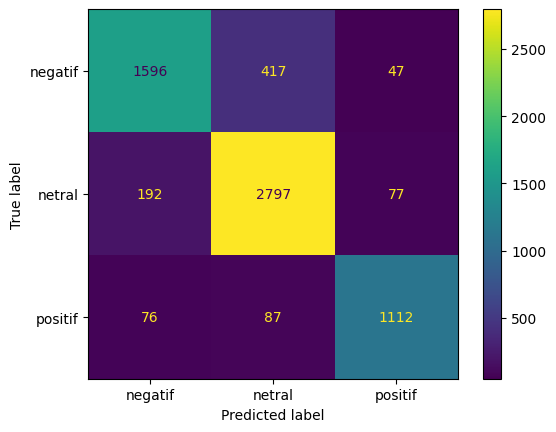

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.show()

###Interpretasi Hasil Logistic Regression

Logistic Regression memperoleh akurasi sebesar 86,29% pada data testing. Model mampu mengklasifikasikan ketiga kelas sentimen dengan baik, terutama pada kelas netral yang memiliki recall tertinggi sebesar 91%.

Kelas positif menunjukkan performa yang sangat baik dengan precision sebesar 90% dan F1-score sebesar 89%, sedangkan kelas negatif memperoleh F1-score sebesar 81%. Hasil ini menunjukkan bahwa representasi TF-IDF mampu menangkap pola sentimen pada komentar transportasi modern Indonesia secara efektif.

Secara keseluruhan, Logistic Regression dapat digunakan sebagai baseline model yang kuat dengan weighted average F1-score sebesar 86%.

##18. Eksperimen 2 — TF-IDF + Linear Support Vector Machine (SVM)
### Tujuan

Membandingkan performa Logistic Regression dengan algoritma Support Vector Machine (SVM). SVM dikenal sangat efektif untuk klasifikasi teks karena mampu memisahkan kelas menggunakan hyperplane optimal pada ruang fitur berdimensi tinggi.

In [40]:
from sklearn.svm import LinearSVC

##18.1 Membangun Model

In [41]:
svm_model = LinearSVC(
    class_weight="balanced"
)

##18.2 Training Model

In [42]:
svm_model.fit(
    X_train_tfidf,
    y_train
)

LinearSVC(class_weight='balanced')

##18.3 Prediction

In [43]:
y_pred_svm = svm_model.predict(
    X_test_tfidf
)

##18.4 Accuracy

In [44]:
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print(
    "Accuracy:",
    round(accuracy_svm,4)
)

Accuracy: 0.8667


##18.5 Classification Report

In [45]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

     negatif       0.87      0.79      0.82      2060
      netral       0.85      0.92      0.88      3066
     positif       0.92      0.87      0.89      1275

    accuracy                           0.87      6401
   macro avg       0.88      0.86      0.87      6401
weighted avg       0.87      0.87      0.87      6401



## 18.6 Confusion Matrix

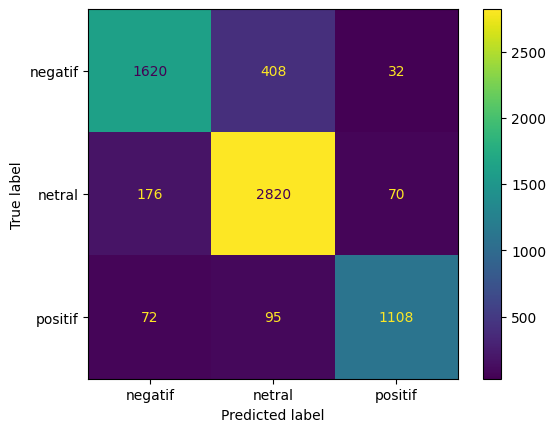

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.show()

### Interpretasi Hasil SVM


Model Linear SVM memperoleh akurasi sebesar 86,67% pada data testing, sedikit lebih tinggi dibandingkan Logistic Regression yang memperoleh akurasi sebesar 86,29%.

Berdasarkan classification report, model menunjukkan performa yang konsisten pada ketiga kelas sentimen. Kelas netral memperoleh recall tertinggi sebesar 92%, menunjukkan bahwa sebagian besar komentar netral berhasil diklasifikasikan dengan benar. Hal ini sejalan dengan dominasi kelas netral dalam dataset.

Pada kelas positif, model memperoleh precision sebesar 92% dan F1-score sebesar 89%, menunjukkan kemampuan yang sangat baik dalam mengenali komentar yang mengandung apresiasi terhadap transportasi modern Indonesia. Sementara itu, kelas negatif memperoleh F1-score sebesar 82%, sedikit lebih baik dibandingkan Logistic Regression.

Secara keseluruhan, nilai weighted average F1-score sebesar 87% menunjukkan bahwa kombinasi TF-IDF dan Linear SVM mampu memberikan performa yang sangat baik dalam klasifikasi sentimen multiclass. Hasil ini menunjukkan bahwa SVM lebih efektif dalam memisahkan fitur-fitur sentimen pada ruang vektor TF-IDF dibandingkan Logistic Regression.

## 19. EKSPERIMEN 3 - Bidirectional Long Short-Term Memory (BiLSTM)
###Tujuan
Membangun model Deep Learning untuk memahami konteks kata yang lebih kompleks dibandingkan model Machine Learning tradisional. Model yang digunakan adalah Bidirectional Long Short-Term Memory (BiLSTM) yang mampu membaca urutan kata dari dua arah sehingga dapat menangkap konteks kalimat dengan lebih baik.

##19.1 Import Library Tensorflow

In [47]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from sklearn.preprocessing import LabelEncoder

##19.2 Encode Label
Model Deep Learning hanya dapat membaca angka.

In [48]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df["sentiment"]
)

print(
    label_encoder.classes_
)

['negatif' 'netral' 'positif']


## 19.3 Tokenisasi

In [49]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df["processed_text"]
)

##19.4 Ubah Teks ke Sequence

In [50]:
sequences = tokenizer.texts_to_sequences(
    df["processed_text"]
)

## 19.5 Padding

In [51]:
max_length = 100

X_pad = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print(X_pad.shape)

(32004, 100)


##19.6 Split Data

In [52]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train_dl.shape)
print(X_test_dl.shape)

(25603, 100)
(6401, 100)


##19.7 Membangun Arsitektur BiLSTM
###Tujuan
Membangun model Deep Learning untuk memahami konteks kata dan hubungan antar kata yang lebih kompleks dibandingkan model Machine Learning tradisional.

Model yang digunakan adalah Bidirectional Long Short-Term Memory (BiLSTM) yang mampu membaca urutan kata dari dua arah sekaligus.

## 19.7.1 Membangun Model

In [53]:
model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=100
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        3,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


##19.7.2 Compile Model
###Penjelasan
Karena negatif, positif, dan netral ada 3 kelas, maka digunakan sparse_categorical_crossentropy

In [54]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

##19.7.3 Ringkasan Model


In [55]:
model.build(
    input_shape=(None, max_length)
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,267 (5.29 MB)

 Trainable params: 1,387,267 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

## 19.7.4 Callback
Supaya model tidak overfitting

In [56]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

##19.7.5 Training Model

In [57]:
history = model.fit(

    X_train_dl,
    y_train_dl,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 89s 130ms/step - accuracy: 0.7777 - loss: 0.5726 - val_accuracy: 0.8793 - val_loss: 0.3680
Epoch 2/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 144s 132ms/step - accuracy: 0.9111 - loss: 0.2785 - val_accuracy: 0.8875 - val_loss: 0.3340
Epoch 3/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 87s 136ms/step - accuracy: 0.9346 - loss: 0.2013 - val_accuracy: 0.8731 - val_loss: 0.3920
Epoch 4/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 88s 138ms/step - accuracy: 0.9504 - loss: 0.1543 - val_accuracy: 0.8781 - val_loss: 0.4011
Epoch 5/15
641/641 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - accuracy: 0.9605 - loss: 0.1245 - val_accuracy: 0.8739 - val_loss: 0.5211


##19.7.6 Visualisasi Model

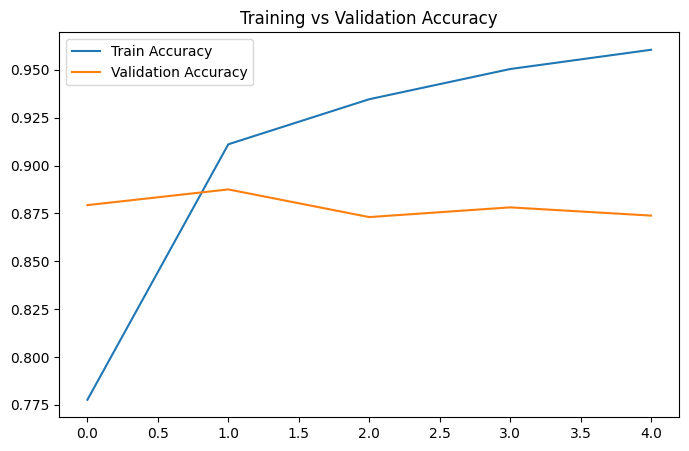

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title(
    "Training vs Validation Accuracy"
)

plt.show()

##19.7.7 Evaluasi Testing


In [59]:
loss, accuracy = model.evaluate(
    X_test_dl,
    y_test_dl
)

print(
    "Test Accuracy:",
    accuracy
)

201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8830 - loss: 0.3435
Test Accuracy: 0.8829870223999023


In [67]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Linear SVM",
        "BiLSTM"
    ],

    "Metode":[
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM",
        "Tokenizer Tensorflow + Embedding + BiLSTM"
    ],

    "Accuracy":[
        0.8629,
        0.8666,
        0.8829
    ]

})

comparison

,Model,Metode,Accuracy
0,Logistic Regression,TF-IDF + Logistic Regression,0.8629
1,Linear SVM,TF-IDF + Linear SVM,0.8666
2,BiLSTM,Tokenizer Tensorflow + Embedding + BiLSTM,0.8829


### Insight Perbandingan Model

Tiga eksperimen dilakukan untuk membandingkan performa algoritma machine learning dan deep learning dalam melakukan klasifikasi sentimen komentar YouTube terkait transportasi modern Indonesia.

Model Logistic Regression dengan fitur TF-IDF memperoleh akurasi sebesar 86,29%. Model ini mampu memberikan performa yang baik dan stabil sebagai baseline model untuk klasifikasi sentimen multiclass.

Model Linear SVM dengan fitur TF-IDF memperoleh akurasi sebesar 86,66%, sedikit lebih tinggi dibandingkan Logistic Regression. Hasil ini menunjukkan bahwa SVM memiliki kemampuan yang lebih baik dalam memisahkan fitur-fitur sentimen pada ruang vektor TF-IDF.

Sementara itu, model BiLSTM yang menggunakan pendekatan deep learning memperoleh akurasi tertinggi sebesar 88,29%. Berbeda dengan Logistic Regression dan SVM yang bergantung pada representasi TF-IDF, BiLSTM mempelajari representasi kata melalui embedding dan mempertimbangkan urutan kata dalam kalimat. Kemampuan ini memungkinkan model memahami konteks kalimat secara lebih baik sehingga menghasilkan performa klasifikasi yang lebih tinggi.

Secara keseluruhan, seluruh model berhasil mencapai akurasi di atas 85%, menunjukkan bahwa proses preprocessing, pelabelan sentimen, dan ekstraksi fitur yang dilakukan telah menghasilkan dataset yang berkualitas untuk tugas klasifikasi sentimen. Berdasarkan hasil evaluasi, BiLSTM dipilih sebagai model terbaik karena memperoleh akurasi tertinggi sebesar 88,29%.

## 20. Inference Model Terbaik (BiLSTM)

Tahap inference dilakukan untuk menguji kemampuan model terbaik dalam memprediksi sentimen pada komentar baru yang belum pernah dilihat selama proses pelatihan.

Model yang digunakan adalah BiLSTM karena menghasilkan performa terbaik dengan akurasi testing sebesar 88,29%.

Pada tahap ini digunakan beberapa contoh komentar yang merepresentasikan sentimen positif, negatif, dan netral terhadap transportasi modern Indonesia.

###20.1 Contoh Sentimen Positif

In [61]:
text_positive = """
Whoosh sangat nyaman, cepat, bersih dan membuat perjalanan Jakarta Bandung menjadi jauh lebih efisien.
"""

text_positive_clean = clean_text(text_positive)
text_positive_clean = remove_stopwords(text_positive_clean)
text_positive_clean = normalize_repeated_chars(text_positive_clean)
text_positive_clean = normalize_slang(text_positive_clean)

print(text_positive_clean)

whoosh sangat nyaman cepat bersih membuat perjalanan jakarta bandung menjadi jauh lebih efisien


In [62]:
seq = tokenizer.texts_to_sequences(
    [text_positive_clean]
)

pad = pad_sequences(
    seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

prediction = model.predict(pad)

pred_class = np.argmax(prediction)

label_map = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

print("Prediksi Sentimen:", label_map[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
Prediksi Sentimen: positif


### Insight

Komentar tersebut mengandung kata-kata seperti "nyaman", "cepat", "bersih", dan "efisien" yang menunjukkan opini positif terhadap layanan transportasi modern.

Model berhasil mengklasifikasikan komentar sebagai sentimen positif.

##20.2 Contoh Sentimen Negatif

In [63]:
text_negative = """
Proyek ini terlalu mahal, merugikan negara dan tidak memberikan manfaat yang sebanding dengan biaya yang dikeluarkan.
"""

text_negative_clean = clean_text(text_negative)
text_negative_clean = remove_stopwords(text_negative_clean)
text_negative_clean = normalize_repeated_chars(text_negative_clean)
text_negative_clean = normalize_slang(text_negative_clean)

seq = tokenizer.texts_to_sequences(
    [text_negative_clean]
)

pad = pad_sequences(
    seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

prediction = model.predict(pad)

pred_class = np.argmax(prediction)

print("Prediksi Sentimen:", label_map[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediksi Sentimen: negatif


### Insight

Komentar mengandung kata-kata seperti "mahal", "merugikan", dan "tidak memberikan manfaat" yang menunjukkan opini negatif.

Model berhasil mengidentifikasi komentar sebagai sentimen negatif.

##20.3 Contoh Sentimen Netral

In [64]:
text_neutral = """
Saya berangkat dari Stasiun Halim menuju Padalarang menggunakan Whoosh.
"""

text_neutral_clean = clean_text(text_neutral)
text_neutral_clean = remove_stopwords(text_neutral_clean)
text_neutral_clean = normalize_repeated_chars(text_neutral_clean)
text_neutral_clean = normalize_slang(text_neutral_clean)

seq = tokenizer.texts_to_sequences(
    [text_neutral_clean]
)

pad = pad_sequences(
    seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

prediction = model.predict(pad)

pred_class = np.argmax(prediction)

print("Prediksi Sentimen:", label_map[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediksi Sentimen: netral


### Kesimpulan Inference

Hasil inference menunjukkan bahwa model BiLSTM mampu mengklasifikasikan komentar baru ke dalam tiga kategori sentimen, yaitu positif, negatif, dan netral.

Pengujian pada beberapa contoh komentar menunjukkan bahwa model dapat mengenali pola bahasa yang merepresentasikan opini pengguna terhadap transportasi modern Indonesia dengan cukup baik.

Hal ini menunjukkan bahwa model tidak hanya bekerja pada data pelatihan dan pengujian, tetapi juga dapat digunakan untuk melakukan prediksi pada data baru yang belum pernah dilihat sebelumnya.

| Kalimat                                              | Prediksi |
| ---------------------------------------------------- | -------- |
| Whoosh sangat nyaman dan cepat                       | Positif  |
| Proyek ini mahal dan merugikan negara                | Negatif  |
| Saya berangkat dari Stasiun Halim menuju Padalarang menggunakan Whoosh | Netral   |




In [65]:
# Contoh komentar dunia nyata

text_real = """
Whoosh keren banget, sekarang perjalanan Jakarta Bandung jadi jauh lebih cepat daripada naik mobil.
"""

# preprocessing

text_real_clean = clean_text(text_real)
text_real_clean = remove_stopwords(text_real_clean)
text_real_clean = normalize_repeated_chars(text_real_clean)
text_real_clean = normalize_slang(text_real_clean)

print("Hasil Preprocessing:")
print(text_real_clean)

# tokenisasi

seq = tokenizer.texts_to_sequences(
    [text_real_clean]
)

# padding

pad = pad_sequences(
    seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# prediksi

prediction = model.predict(pad)

pred_class = np.argmax(prediction)

label_map = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

print("\nProbabilitas Prediksi:")
print(prediction)

print("\nPrediksi Sentimen:")
print(label_map[pred_class])

Hasil Preprocessing:
whoosh keren banget sekarang perjalanan jakarta bandung jauh lebih cepat naik mobil
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

Probabilitas Prediksi:
[[3.0009216e-04 1.1792784e-03 9.9852067e-01]]

Prediksi Sentimen:
positif


In [66]:
### END OF CODE ###